# Probing in Code LLMs — Boolean

In [1]:
# Installs into whatever Python this notebook kernel uses (top-right kernel picker).
import subprocess
import sys
import os

def _ensure_notebook_deps():
    try:
        import torch  # noqa: F401
        import transformers  # noqa: F401
        import sklearn  # noqa: F401
        import matplotlib.pyplot  # noqa: F401
        import seaborn  # noqa: F401
        import tqdm  # noqa: F401
    except ModuleNotFoundError:
        pkgs = [
            "numpy>=1.26,<2", "scipy>=1.15", "torch", "transformers",
            "scikit-learn", "matplotlib", "seaborn", "tqdm",
        ]
        subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])

_ensure_notebook_deps()

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from collections import defaultdict
import ast
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = os.path.join(os.getcwd(), 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'  

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Qwen has no pad token separate from eos — set one so batched calls don't warn
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)
model.eval()
model.to(DEVICE)

NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'Layers: {NUM_LAYERS}, Hidden size: {HIDDEN_SIZE}')

_probe_ids = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
_raw_len   = len(tokenizer.tokenize('x'))
LEADING_SPECIAL = len(_probe_ids) - _raw_len   # 1 for BERT, 0 for Qwen
print(f'Leading special tokens detected: {LEADING_SPECIAL}  '
      f'(e.g. [CLS] for BERT=1, none for Qwen=0)')

Loading tokenizer and model: Qwen/Qwen2.5-1.5B ...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 3557.93it/s]

Layers: 28, Hidden size: 1536
Leading special tokens detected: 0  (e.g. [CLS] for BERT=1, none for Qwen=0)



## Dataset 

In [3]:
import csv
import os, json

XLCOST_ROOT    = '../XLCoST_data'
NL2CODE_PROG   = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')


def reconstruct_code(tokens):
    indent_level = 0
    lines        = []
    current_line = []

    for tok in tokens:
        if tok == 'NEW_LINE':
            lines.append('    ' * indent_level + ' '.join(current_line))
            current_line = []
        elif tok == 'INDENT':
            indent_level += 1
        elif tok == 'DEDENT':
            indent_level = max(0, indent_level - 1)
        else:
            current_line.append(tok)

    if current_line:
        lines.append('    ' * indent_level + ' '.join(current_line))

    return '\n'.join(lines).strip()


def load_xlcost_programs(language, split='train', max_programs=300):
    path = os.path.join(NL2CODE_PROG, language, f'{split}.jsonl')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')

    programs = []
    with open(path) as f:
        for line in f:
            if len(programs) >= max_programs:
                break
            rec  = json.loads(line.strip())
            code = reconstruct_code(rec['code_tokens'])
            if code:
                programs.append(code)
    return programs


def load_synthetic_boolean_csv(csv_path='dataset/python/boolean/synthetic_boolean_dataset.csv'):
    """Load program strings from standalone CSV (column ``code``), ordered by ``example_id``."""
    path = csv_path if os.path.isabs(csv_path) else os.path.join(os.getcwd(), csv_path)
    if not os.path.isfile(path):
        print(f'[synthetic_boolean_dataset] File not found (skip): {path}')
        return []
    rows = []
    with open(path, encoding='utf-8', newline='') as f:
        for rec in csv.DictReader(f):
            rows.append(rec)

    def _row_id(rec):
        try:
            return int(rec['example_id'])
        except (KeyError, ValueError):
            return 0

    rows.sort(key=_row_id)
    out = [r['code'] for r in rows if r.get('code')]
    print(f'Loaded {len(out)} synthetic boolean examples from {path}')
    return out


print('Loading Python programs from XLCoST (program_level) ...')
PYTHON_PROGRAMS = load_xlcost_programs('Python', split='train', max_programs=500)
print(f'Loaded {len(PYTHON_PROGRAMS)} Python programs')

print('\n── Sample program #0 ──────────────────────────────────────────')
print(PYTHON_PROGRAMS[0])
print('\n── Sample program #1 ──────────────────────────────────────────')
print(PYTHON_PROGRAMS[1][:400])

SYNTHETIC_BOOL_SAMPLES = load_synthetic_boolean_csv('dataset/python/boolean/synthetic_boolean_dataset.csv')


Loading Python programs from XLCoST (program_level) ...
Loaded 500 Python programs

── Sample program #0 ──────────────────────────────────────────
def maxPresum ( a , b ) :
    X = max ( a [ 0 ] , 0 )
    for i in range ( 1 , len ( a ) ) :
        a [ i ] += a [ i - 1 ]
        X = max ( X , a [ i ] )
    Y = max ( b [ 0 ] , 0 )
    for i in range ( 1 , len ( b ) ) :
        b [ i ] += b [ i - 1 ]
        Y = max ( Y , b [ i ] )
    return X + Y
A = [ 2 , - 1 , 4 , - 5 ]
B = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( maxPresum ( A , B ) )

── Sample program #1 ──────────────────────────────────────────
import math
def sumOfTwoCubes ( n ) :
    lo = 1
    hi = round ( math . pow ( n , 1 / 3 ) )
    while ( lo <= hi ) :
        curr = ( lo * lo * lo + hi * hi * hi )
        if ( curr == n ) :
            return True
        if ( curr < n ) :
            lo += 1
        else :
            hi -= 1
    return False
N = 28
if ( sumOfTwoCubes ( N ) ) :
    print ( " True " )
else :
    print ( " Fal

## Tokenization


In [4]:
def show_tokens(code_str, n_show=20):
    tokens = tokenizer.tokenize(code_str)
    ids    = tokenizer.convert_tokens_to_ids(tokens)
    print(f'Code: {repr(code_str[:120])}')
    print(f'Tokens ({len(tokens)} total):')
    for tok, tid in zip(tokens[:n_show], ids[:n_show]):
        print(f'  {tid:>8}  {repr(tok)}')
    print()

show_tokens('ok = True\nerr = False\nprint(ok)\nprint(err)')


Code: 'ok = True\nerr = False\nprint(ok)\nprint(err)'
Tokens (14 total):
       562  'ok'
       284  'Ġ='
      3007  'ĠTrue'
       198  'Ċ'
       615  'err'
       284  'Ġ='
      3557  'ĠFalse'
       198  'Ċ'
      1350  'print'
     60207  '(ok'
       340  ')Ċ'
      1350  'print'
      3964  '(err'
         8  ')'



In [5]:
# Tokenizer splits on boolean-heavy snippets (model-dependent)
for snippet in ['a = True', 'print(flag_t)', 'x = False\ny = x']:
    print(repr(snippet), '->', tokenizer.tokenize(snippet))


'a = True' -> ['a', 'Ġ=', 'ĠTrue']
'print(flag_t)' -> ['print', '(flag', '_t', ')']
'x = False\ny = x' -> ['x', 'Ġ=', 'ĠFalse', 'Ċ', 'y', 'Ġ=', 'Ġx']


### Boolean probing task

- **Label 1** → token is a **use** of a variable that **currently** holds `True` (under a sequential AST walk; only literal `True`/`False` assignments update the environment).
- **Label 0** → token is a **use** of a variable that **currently** holds `False`.
- **Label −1** (masked) → not a probe site (excluded from `X`, `y`).

Training uses `LogisticRegression(..., class_weight='balanced', solver='lbfgs')` on tokens with labels in `{0, 1}`.


In [6]:
def is_boolean_assignment(node):
    return (
        isinstance(node, ast.Assign)
        and isinstance(node.value, ast.Constant)
        and isinstance(node.value.value, bool)
    )

def _line_start_indices(code):
    """Char index where each 1-based source line begins (ast cols are line-relative)."""
    starts = [0]
    for i, ch in enumerate(code):
        if ch == '\n':
            starts.append(i + 1)
    return starts


def _record_bool_name_loads(expr, env, spans_out, line_starts):
    if expr is None:
        return
    for sub in ast.walk(expr):
        if isinstance(sub, ast.Name) and isinstance(sub.ctx, ast.Load):
            if sub.id in env and isinstance(env[sub.id], bool):
                lbl = 1 if env[sub.id] is True else 0
                ln = sub.lineno
                if ln < 1 or ln > len(line_starts):
                    continue
                base = line_starts[ln - 1]
                c0 = sub.col_offset
                c1 = getattr(sub, 'end_col_offset', None)
                if c1 is None:
                    c1 = c0 + len(sub.id)
                spans_out.append((base + c0, base + c1, lbl))

def _apply_bool_assign_targets(stmt, env):
    if not is_boolean_assignment(stmt):
        return
    val = stmt.value.value
    for t in stmt.targets:
        if isinstance(t, ast.Name):
            env[t.id] = val

def collect_boolean_use_spans(code):
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return []
    line_starts = _line_start_indices(code)
    spans = []
    def process_stmts(stmts, env):
        for stmt in stmts:
            if isinstance(stmt, ast.Assign):
                _record_bool_name_loads(stmt.value, env, spans, line_starts)
                _apply_bool_assign_targets(stmt, env)
            elif isinstance(stmt, ast.AnnAssign) and stmt.value is not None:
                _record_bool_name_loads(stmt.value, env, spans, line_starts)
                if isinstance(stmt.value, ast.Constant) and isinstance(stmt.value.value, bool):
                    if isinstance(stmt.target, ast.Name):
                        env[stmt.target.id] = stmt.value.value
            elif isinstance(stmt, ast.AugAssign):
                _record_bool_name_loads(stmt.value, env, spans, line_starts)
            elif isinstance(stmt, ast.Expr):
                _record_bool_name_loads(stmt.value, env, spans, line_starts)
            elif isinstance(stmt, ast.If):
                _record_bool_name_loads(stmt.test, env, spans, line_starts)
                process_stmts(stmt.body, env.copy())
                process_stmts(stmt.orelse, env.copy())
            elif isinstance(stmt, ast.For):
                _record_bool_name_loads(stmt.iter, env, spans, line_starts)
                process_stmts(stmt.body, env.copy())
                process_stmts(stmt.orelse, env.copy())
            elif isinstance(stmt, ast.While):
                _record_bool_name_loads(stmt.test, env, spans, line_starts)
                process_stmts(stmt.body, env.copy())
                process_stmts(stmt.orelse, env.copy())
            elif isinstance(stmt, ast.With):
                for item in stmt.items:
                    _record_bool_name_loads(item.context_expr, env, spans, line_starts)
                process_stmts(stmt.body, env.copy())
            elif isinstance(stmt, (ast.FunctionDef, ast.AsyncFunctionDef)):
                process_stmts(stmt.body, {})
            elif isinstance(stmt, ast.ClassDef):
                process_stmts(stmt.body, env.copy())
    process_stmts(tree.body, {})
    return spans

def label_tokens_boolean(code):
    spans = collect_boolean_use_spans(code)
    if not spans:
        return [], []
    try:
        enc = tokenizer(code, add_special_tokens=False, return_offsets_mapping=True, truncation=False)
    except (TypeError, ValueError):
        return [], []
    offsets = enc['offset_mapping']
    ids = enc['input_ids']
    if hasattr(ids, 'tolist'):
        ids = ids.tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)
    labels = []
    for (cs, ce), _tok in zip(offsets, tokens):
        if ce <= cs:
            labels.append(-1)
            continue
        lab = -1
        for s, e, lbl in spans:
            if max(cs, s) < min(ce, e):
                lab = lbl
                break
        labels.append(lab)
    return tokens, labels

def build_boolean_dataset(snippets, role_name='boolean_tf'):
    dataset = []
    skipped = 0
    for code in snippets:
        tokens, labels = label_tokens_boolean(code)
        probe = [lb for lb in labels if lb >= 0]
        if not tokens or not probe:
            skipped += 1
            continue
        spans = collect_boolean_use_spans(code)
        dataset.append({
            'code': code, 'tokens': tokens, 'labels': labels,
            'target_names': {code[s:e] for s, e, _ in spans},
            'role': role_name,
        })
    n_probe = sum(sum(1 for lb in d['labels'] if lb >= 0) for d in dataset)
    n_tok = sum(len(d['tokens']) for d in dataset)
    n1 = sum(sum(1 for lb in d['labels'] if lb == 1) for d in dataset)
    n0 = sum(sum(1 for lb in d['labels'] if lb == 0) for d in dataset)
    print(f'[{role_name:12s}] {len(dataset)} programs, {skipped} skipped')
    print(f'               {n_probe} probe tokens ({n1} True-uses, {n0} False-uses) / {n_tok} tokenizer positions')
    if dataset and (n1 == 0 or n0 == 0):
        print(f'               WARNING: global class imbalance (need both 0 and 1 for probing).')
    return dataset

_demo = 'ok = True\nerr = False\nprint(ok)\nprint(err)\n'
_dt, _dl = label_tokens_boolean(_demo)
print('Demo labels (1=True use, 0=False, -1=masked):')
for t, lb in list(zip(_dt, _dl))[:36]:
    print(f'  {repr(t):18s}  {lb}')

_BOOLEAN_FALLBACK = [
    'flag_t = True\nflag_f = False\nprint(flag_t)\nprint(flag_f)\n',
]
boolean_data = build_boolean_dataset(
    PYTHON_PROGRAMS + _BOOLEAN_FALLBACK + SYNTHETIC_BOOL_SAMPLES,
    role_name='boolean_tf',
)

if boolean_data:
    _s = boolean_data[0]
    print('\nFirst training sample — tokens with probe labels (first 40):')
    for tok, lab in list(zip(_s['tokens'], _s['labels']))[:40]:
        m = '  <-- PROBE' if lab >= 0 else ''
        print(f'  {repr(tok):18s} {lab}{m}')



Demo labels (1=True use, 0=False, -1=masked):
  'ok'                -1
  'Ġ='                -1
  'ĠTrue'             -1
  'Ċ'                 -1
  'err'               -1
  'Ġ='                -1
  'ĠFalse'            -1
  'Ċ'                 -1
  'print'             -1
  '(ok'               1
  ')Ċ'                -1
  'print'             -1
  '(err'              0
  ')Ċ'                -1
[boolean_tf  ] 505 programs, 496 skipped
               2862 probe tokens (1194 True-uses, 1668 False-uses) / 34039 tokenizer positions

First training sample — tokens with probe labels (first 40):
  'def'              -1
  'Ġcount'           -1
  'Ġ('               -1
  'Ġa'               -1
  'Ġ,'               -1
  'Ġn'               -1
  'Ġ)'               -1
  'Ġ:Ċ'              -1
  'ĠĠĠ'              -1
  'Ġcount'           -1
  'Elements'         -1
  'Ġ='               -1
  'Ġ'                -1
  '0'                -1
  'Ċ'                -1
  'ĠĠĠ'              -1
  'Ġfor'             -1


## Hidden state extraction


In [7]:
from tqdm.auto import tqdm

MAX_SEQ_LEN = 512

def extract_hidden_states_boolean(dataset):
    """Stack hidden vectors for every content token with label 0 or 1."""
    all_hidden     = defaultdict(list)
    all_labels     = []
    all_token_strs = []
    valid = (0, 1)

    with torch.no_grad():
        for sample in tqdm(dataset, desc='Extracting hidden states'):
            code   = sample['code']
            labels = sample['labels']

            encoding = tokenizer(code, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LEN, padding=False).to(DEVICE)
            encoded_len = encoding['input_ids'].shape[1]
            n_content   = encoded_len - LEADING_SPECIAL

            tokens_no_special = tokenizer.tokenize(code)
            labels_trunc = labels[:n_content]
            tokens_trunc = tokens_no_special[:n_content]

            outputs = model(**encoding)
            hidden_states = outputs.hidden_states
            start = LEADING_SPECIAL

            for ti in range(n_content):
                lab = labels_trunc[ti]
                if lab not in valid:
                    continue
                for layer_idx, layer_hs in enumerate(hidden_states):
                    vec = layer_hs[0, start + ti, :].float().cpu().numpy()
                    all_hidden[layer_idx].append(vec)
                all_labels.append(lab)
                all_token_strs.append(tokens_trunc[ti])

    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.stack(all_hidden[layer_idx])

    return all_hidden, np.array(all_labels), all_token_strs

if not boolean_data:
    raise RuntimeError('boolean_data is empty — check XLCoST path or filters.')

bool_hidden, bool_labels, bool_tokens = extract_hidden_states_boolean(boolean_data)
print(f'Layer 0 shape: {bool_hidden[0].shape}  |  labels (0=False, 1=True): {np.bincount(bool_labels)}')


Extracting hidden states: 100%|██████████| 505/505 [53:39<00:00,  6.38s/it]  


Layer 0 shape: (2862, 1536)  |  labels (0=False, 1=True): [1668 1194]


## Probe training


In [8]:
def train_probes(hidden_states_by_layer, labels, test_size=0.2, random_state=42):
    n = len(labels)
    uniq = np.unique(labels)
    strat = labels if len(uniq) > 1 else None
    train_idx, test_idx = train_test_split(
        np.arange(n), test_size=test_size, random_state=random_state, stratify=strat
    )
    results = {}
    for layer_idx in tqdm(sorted(hidden_states_by_layer.keys()), desc='Training probes'):
        X = hidden_states_by_layer[layer_idx]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=random_state,
            C=1.0,
            solver='lbfgs',
        )
        clf.fit(X_train, y_train)
        y_pred_train = clf.predict(X_train)
        y_pred_test = clf.predict(X_test)
        results[layer_idx] = {
            'train_acc': accuracy_score(y_train, y_pred_train),
            'test_acc': accuracy_score(y_test, y_pred_test),
            'train_f1': f1_score(y_train, y_pred_train, zero_division=0),
            'test_f1': f1_score(y_test, y_pred_test, zero_division=0),
            'test_precision': precision_score(y_test, y_pred_test, zero_division=0),
            'test_recall': recall_score(y_test, y_pred_test, zero_division=0),
            'probe': clf,
            'test_idx': test_idx,
        }
    return results

if len(bool_labels) < 20:
    print('Warning: very few boolean probe tokens; metrics may be unstable.')

bool_results = train_probes(bool_hidden, bool_labels)


Training probes: 100%|██████████| 29/29 [00:18<00:00,  1.60it/s]


## Evaluation and visualization


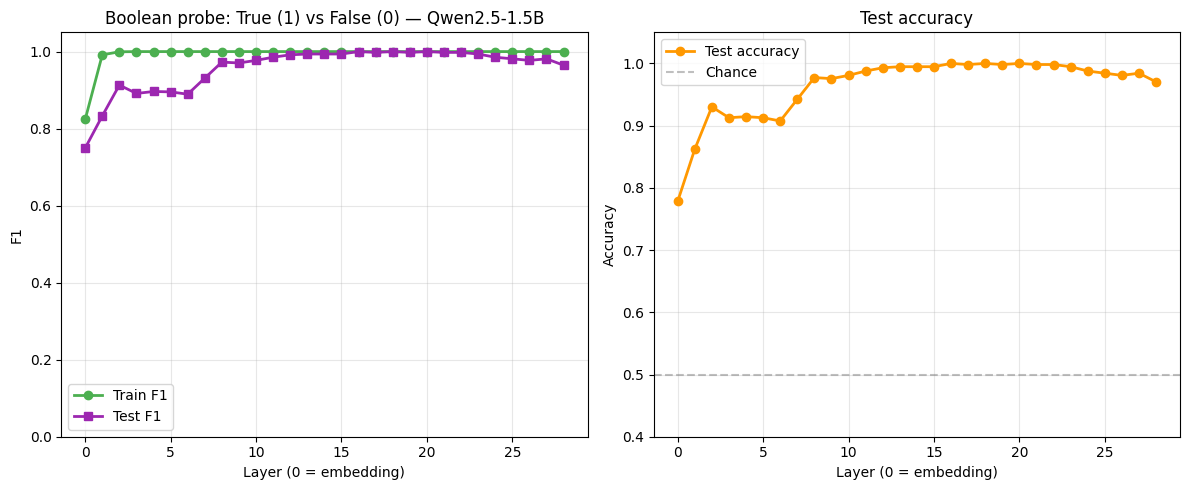

Saved: probe_f1_boolean.png


In [9]:
layers = sorted(bool_results.keys())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
train_f1 = [bool_results[l]['train_f1'] for l in layers]
test_f1 = [bool_results[l]['test_f1'] for l in layers]
ax[0].plot(layers, train_f1, marker='o', color='#4CAF50', linewidth=2, label='Train F1')
ax[0].plot(layers, test_f1, marker='s', color='#9C27B0', linewidth=2, label='Test F1')
ax[0].set_xlabel('Layer (0 = embedding)')
ax[0].set_ylabel('F1')
ax[0].set_title(f'Boolean probe: True (1) vs False (0) — {MODEL_NAME.split("/")[-1]}')
ax[0].set_ylim(0, 1.05)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

test_acc = [bool_results[l]['test_acc'] for l in layers]
ax[1].plot(layers, test_acc, marker='o', color='#FF9800', linewidth=2, label='Test accuracy')
ax[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax[1].set_xlabel('Layer (0 = embedding)')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Test accuracy')
ax[1].set_ylim(0.4, 1.05)
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
_probe_plot_path = os.path.join(OUTPUT_DIR, 'probe_f1_boolean.png')
plt.savefig(_probe_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_probe_plot_path}')


In [10]:
print(f'{"Layer":>7}  {"Tr Acc":>8}  {"Te Acc":>8}  {"Tr F1":>8}  {"Te F1":>8}  {"P":>8}  {"R":>8}')
print('-' * 60)
for l in layers:
    r = bool_results[l]
    print(f'{l:>7}  {r["train_acc"]:>8.3f}  {r["test_acc"]:>8.3f}  {r["train_f1"]:>8.3f}  {r["test_f1"]:>8.3f}  {r["test_precision"]:>8.3f}  {r["test_recall"]:>8.3f}')


  Layer    Tr Acc    Te Acc     Tr F1     Te F1         P         R
------------------------------------------------------------
      0     0.843     0.778     0.824     0.750     0.709     0.795
      1     0.993     0.862     0.992     0.833     0.842     0.824
      2     1.000     0.930     0.999     0.913     0.950     0.879
      3     1.000     0.913     1.000     0.891     0.928     0.858
      4     1.000     0.914     1.000     0.896     0.906     0.887
      5     1.000     0.913     1.000     0.895     0.895     0.895
      6     1.000     0.908     1.000     0.889     0.887     0.891
      7     1.000     0.942     1.000     0.931     0.929     0.933
      8     1.000     0.977     1.000     0.973     0.979     0.967
      9     1.000     0.976     1.000     0.970     0.979     0.962
     10     1.000     0.981     1.000     0.977     0.971     0.983
     11     1.000     0.988     1.000     0.985     0.983     0.987
     12     1.000     0.993     1.000     0.992     0.9

In [11]:
best_layer = max(bool_results, key=lambda l: bool_results[l]['test_f1'])
test_idx = bool_results[best_layer]['test_idx']
clf = bool_results[best_layer]['probe']
X_test = bool_hidden[best_layer][test_idx]
y_test = bool_labels[test_idx]
y_pred = clf.predict(X_test)
f1 = f1_score(y_test, y_pred)

print(f'Best layer (by test F1): {best_layer}')
print(f'Test accuracy: {bool_results[best_layer]["test_acc"]:.3f}  |  test F1: {f1:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['holds False (0)', 'holds True (1)']))


Best layer (by test F1): 16
Test accuracy: 1.000  |  test F1: 1.000

                 precision    recall  f1-score   support

holds False (0)       1.00      1.00      1.00       334
 holds True (1)       1.00      1.00      1.00       239

       accuracy                           1.00       573
      macro avg       1.00      1.00      1.00       573
   weighted avg       1.00      1.00      1.00       573

